## Workflow Structure

The notebook is organized as a sequential exploratory workflow:

1. environment setup
2. sequence and signal preparation
3. optimization of the core system
4. inspection of learning dynamics
5. reconstruction on a known example
6. generation from a new prompt


In [1]:
from dataclasses import dataclass
from pathlib import Path
import copy
import math
import random
import importlib.util
import time

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from IPython.display import Audio, display, clear_output
import ipywidgets as widgets


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(42)


@dataclass
class Config:
    project_dir: Path = Path('.')
    metadata_path: Path = project_dir / 'metadata2.csv'
    wav_dir: Path = project_dir / 'golden_set_2'
    sample_rate: int = 22050
    n_fft: int = 1024
    hop_length: int = 256
    win_length: int = 1024
    n_mels: int = 80
    fmin: int = 0
    fmax: int = 8000

    hidden_size: int = 512
    encoder_dropout: float = 0.1
    attention_dropout: float = 0.1
    encoder_num_layers: int = 6
    encoder_num_heads: int = 8
    encoder_prenet_layers: int = 3
    encoder_kernel_size: int = 5
    encoder_ffn_kernel_size: int = 3
    encoder_ffn_multiplier: int = 4
    encoder_max_relative_position: int = 4
    duration_predictor_layers: int = 2
    duration_predictor_kernel_size: int = 3
    duration_predictor_filter_size: int = 256
    decoder_layers: int = 6
    decoder_base_channels: int = 64
    decoder_dropout: float = 0.1
    prior_layers: int = 3
    prior_kernel_size: int = 5
    detach_duration_predictor_input: bool = True
    diffusion_beta_min: float = 0.05
    diffusion_beta_max: float = 20.0
    diffusion_pe_scale: int = 1000
    diffusion_dim_mults: tuple = (1, 2, 4)
    diffusion_groups: int = 8
    diffusion_stochastic: bool = False
    diffusion_temperature_mode: str = 'inverse'
    diffusion_steps: int = 80
    diffusion_x0_loss_weight: float = 0.05
    diffusion_sample_clamp_value: float = 4.0
    decoder_train_segment_frames: int = 192
    max_noise_level: float = 1.0
    min_noise_level: float = 0.05
    inference_temperature: float = 2.0
    length_scale: float = 1.0
    max_predicted_duration: int = 30

    batch_size: int = 2
    grad_accum_steps: int = 4
    learning_rate: float = 2e-4
    min_learning_rate: float = 2e-5
    weight_decay: float = 1e-4
    lr_warmup_epochs: int = 5
    ema_decay: float = 0.999
    use_ema: bool = True
    max_grad_norm: float = 1.0
    epochs: int = 80
    duration_loss_weight: float = 0.05
    l2_loss_weight: float = 0.5
    refinement_blend: float = 0.35
    prior_loss_weight: float = 1.0
    loader_workers: int = 0
    batch_log_every: int = 25
    log_to_stdout: bool = True
    stdout_log_every: int = 10
    max_train_batches: int = 0
    use_amp: bool = True

    checkpoint_path: Path = project_dir / 'compact_speech_pipeline_v2.pt'
    last_checkpoint_path: Path = project_dir / 'compact_speech_pipeline_v2_last.pt'
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'


config = Config()
print(config)


Config(project_dir=WindowsPath('.'), metadata_path=WindowsPath('metadata2.csv'), wav_dir=WindowsPath('golden_set_2'), sample_rate=22050, n_fft=1024, hop_length=256, win_length=1024, n_mels=80, fmin=0, fmax=8000, hidden_size=512, encoder_dropout=0.1, attention_dropout=0.1, encoder_num_layers=6, encoder_num_heads=8, encoder_prenet_layers=3, encoder_kernel_size=5, encoder_ffn_kernel_size=3, encoder_ffn_multiplier=4, encoder_max_relative_position=4, duration_predictor_layers=2, duration_predictor_kernel_size=3, duration_predictor_filter_size=256, decoder_layers=6, decoder_base_channels=64, decoder_dropout=0.1, prior_layers=3, prior_kernel_size=5, detach_duration_predictor_input=False, diffusion_beta_min=0.05, diffusion_beta_max=20.0, diffusion_pe_scale=1000, diffusion_dim_mults=(1, 2, 4), diffusion_groups=8, diffusion_stochastic=False, diffusion_temperature_mode='inverse', diffusion_steps=80, diffusion_x0_loss_weight=0.05, diffusion_sample_clamp_value=4.0, decoder_train_segment_frames=192,

## Starting Point

The workflow assumes paired text and speech are already available in the working environment.


In [2]:
REQUIRED_PACKAGES = ["torch", "torchaudio", "librosa", "soundfile", "pandas", "numpy", "matplotlib", "tqdm"]
missing = [pkg for pkg in REQUIRED_PACKAGES if importlib.util.find_spec(pkg) is None]
if missing:
    raise RuntimeError(f"Install missing packages first: pip install {' '.join(missing)}")

assert config.metadata_path.exists(), config.metadata_path
assert config.wav_dir.exists(), config.wav_dir

## Data Preparation

A symbol-level representation is paired with observed timing information.

- text is converted into a sequence of symbols
- each recording is mapped into a compact spectral view
- token timing is inferred automatically from paired examples
- durations are projected onto frame space so the timing covers the full representation

This produces supervision tied to observed temporal structure rather than a uniform allocation of frames.


In [3]:
def normalize_text(text: str) -> str:
    return " ".join(str(text).lower().strip().split())


class CharTokenizer:
    def __init__(self, texts):
        merged = "".join(texts)
        symbols = ["_"] + sorted(set(merged))
        if "?" not in symbols:
            symbols.append("?")
        self.pad_token = "_"
        self.unk_token = "?"
        self.symbol_to_id = {symbol: idx for idx, symbol in enumerate(symbols)}
        self.id_to_symbol = {idx: symbol for symbol, idx in self.symbol_to_id.items()}
        self.pad_id = self.symbol_to_id[self.pad_token]
        self.unk_id = self.symbol_to_id[self.unk_token]

    def encode(self, text: str):
        text = normalize_text(text)
        return [self.symbol_to_id.get(ch, self.unk_id) for ch in text]

    @property
    def vocab_size(self):
        return len(self.symbol_to_id)


ALIGNMENT_BUNDLE = torchaudio.pipelines.WAV2VEC2_ASR_BASE_960H
ALIGNMENT_LABELS = ALIGNMENT_BUNDLE.get_labels()
ALIGNMENT_DICT = {label: idx for idx, label in enumerate(ALIGNMENT_LABELS)}


def load_audio_mono(wav_path: Path) -> tuple[np.ndarray, int]:
    wav, sr = sf.read(wav_path)
    if wav.ndim == 2:
        wav = wav.mean(axis=1)
    return wav.astype(np.float32), sr


def resample_audio(wav: np.ndarray, orig_sr: int, target_sr: int) -> np.ndarray:
    if orig_sr == target_sr:
        return wav.astype(np.float32)
    return librosa.resample(wav, orig_sr=orig_sr, target_sr=target_sr).astype(np.float32)


def extract_log_mel_from_waveform(wav: np.ndarray, config: Config) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=wav,
        sr=config.sample_rate,
        n_fft=config.n_fft,
        hop_length=config.hop_length,
        win_length=config.win_length,
        n_mels=config.n_mels,
        fmin=config.fmin,
        fmax=config.fmax,
        power=2.0,
    )
    return np.log(np.clip(mel, 1e-5, None)).T.astype(np.float32)


def build_alignment_targets(text: str) -> tuple[list[int], list[int]]:
    token_ids = []
    text_positions = []
    blank_id = ALIGNMENT_DICT["-"]
    word_sep_id = ALIGNMENT_DICT.get("|")

    for idx, ch in enumerate(normalize_text(text)):
        if ch in {" ", "-"} and word_sep_id is not None:
            token_ids.append(word_sep_id)
            text_positions.append(idx)
            continue

        token = ch.upper()
        token_id = ALIGNMENT_DICT.get(token)
        if token_id is not None and token_id != blank_id:
            token_ids.append(token_id)
            text_positions.append(idx)

    return token_ids, text_positions


def token_spans_to_mel_durations(spans, emission_frames: int, mel_frames: int) -> np.ndarray:
    if len(spans) == 0:
        return np.zeros(0, dtype=np.int64)

    boundaries = [0]
    for left, right in zip(spans[:-1], spans[1:]):
        boundaries.append(int(round((left.end + right.start) / 2)))
    boundaries.append(int(emission_frames))

    boundaries = np.asarray(boundaries, dtype=np.float64)
    mel_boundaries = np.rint(boundaries * mel_frames / emission_frames).astype(np.int64)
    mel_boundaries[0] = 0
    mel_boundaries[-1] = mel_frames
    mel_boundaries = np.clip(mel_boundaries, 0, mel_frames)
    mel_boundaries = np.maximum.accumulate(mel_boundaries)
    return np.diff(mel_boundaries)


def align_text_to_mel(
    text: str,
    wav: np.ndarray,
    sr: int,
    mel_frames: int,
    alignment_model,
    device: str,
) -> np.ndarray:
    normalized_text = normalize_text(text)
    token_ids, text_positions = build_alignment_targets(normalized_text)
    if not token_ids:
        raise ValueError("Text has no symbols supported by the alignment model.")

    aligned_wav = resample_audio(wav, sr, ALIGNMENT_BUNDLE.sample_rate)
    waveform = torch.tensor(aligned_wav, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.inference_mode():
        emission, _ = alignment_model(waveform)
        log_probs = torch.log_softmax(emission, dim=-1).cpu()

    aligned_tokens, scores = torchaudio.functional.forced_align(
        log_probs,
        torch.tensor([token_ids], dtype=torch.int32),
        blank=ALIGNMENT_DICT["-"],
    )
    spans = torchaudio.functional.merge_tokens(aligned_tokens[0], scores[0].exp())
    if len(spans) != len(token_ids):
        raise RuntimeError("Alignment produced an unexpected number of token spans.")

    supported_durations = token_spans_to_mel_durations(spans, int(log_probs.shape[1]), mel_frames)
    durations = np.zeros(len(normalized_text), dtype=np.int64)
    for text_idx, duration in zip(text_positions, supported_durations):
        durations[text_idx] = int(duration)

    if durations.sum() != mel_frames:
        raise RuntimeError(f"Aligned durations sum to {durations.sum()} frames, expected {mel_frames}.")

    return durations


metadata = pd.read_csv(
    config.metadata_path,
    sep="|",
    names=["item_id", "raw_text", "normalized_text"],
    quoting=3,
)
metadata["normalized_text"] = metadata["normalized_text"].fillna(metadata["raw_text"]).map(normalize_text)
tokenizer = CharTokenizer(metadata["normalized_text"].tolist())

alignment_model = ALIGNMENT_BUNDLE.get_model().to(config.device)

items = []
for row in tqdm(metadata.itertuples(index=False), total=len(metadata), desc="Preparing aligned data"):
    wav_path = config.wav_dir / f"{row.item_id}.wav"
    if not wav_path.exists():
        continue

    normalized_text = normalize_text(row.normalized_text)
    text_ids = np.asarray(tokenizer.encode(normalized_text), dtype=np.int64)
    if len(text_ids) == 0:
        continue

    wav, sr = load_audio_mono(wav_path)
    mel_wav = resample_audio(wav, sr, config.sample_rate)
    mel = extract_log_mel_from_waveform(mel_wav, config)

    try:
        durations = align_text_to_mel(
            normalized_text,
            wav,
            sr,
            mel.shape[0],
            alignment_model,
            config.device,
        )
    except Exception as err:
        print(f"Skipping {row.item_id}: {err}")
        continue

    items.append(
        {
            "item_id": row.item_id,
            "text": normalized_text,
            "text_ids": torch.tensor(text_ids, dtype=torch.long),
            "durations": torch.tensor(durations, dtype=torch.long),
            "mel_raw": mel,
        }
    )

all_frames = np.concatenate([item["mel_raw"] for item in items], axis=0)
mel_mean = all_frames.mean(axis=0).astype(np.float32)
mel_std = (all_frames.std(axis=0) + 1e-5).astype(np.float32)
mel_min = float(all_frames.min())
mel_max = float(all_frames.max())

for item in items:
    mel_norm = (item["mel_raw"] - mel_mean) / mel_std
    item["mel_norm"] = torch.tensor(mel_norm, dtype=torch.float32)
    item["mel"] = torch.tensor(mel_norm, dtype=torch.float32)

print(f"Loaded items: {len(items)}")
print(f"Vocab size: {tokenizer.vocab_size}")
print("Example:", items[0]["item_id"], items[0]["text"][:120])
print("Text length:", len(items[0]["text_ids"]), "Frames:", len(items[0]["mel"]))
if config.device == "cuda":
    alignment_model = alignment_model.cpu()
    torch.cuda.empty_cache()
del alignment_model


Preparing aligned data:   0%|          | 0/1120 [00:00<?, ?it/s]

Loaded items: 1120
Vocab size: 39
Example: LJ001-0001 printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and craft
Text length: 151 Frames: 832


## Batch Construction

The available pairs are transformed into synchronized tensors and collected into padded batches.

- symbol sequences are assembled
- timing targets are attached
- spectral targets are normalized and padded


In [4]:
class TTSDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __getitem__(self, index):
        return self.items[index]

    def __len__(self):
        return len(self.items)


def pad_1d(tensors, pad_value=0):
    max_len = max(t.shape[0] for t in tensors)
    out = torch.full((len(tensors), max_len), pad_value, dtype=tensors[0].dtype)
    for i, tensor in enumerate(tensors):
        out[i, : tensor.shape[0]] = tensor
    return out


def pad_2d(tensors, pad_value=0.0):
    max_len = max(t.shape[0] for t in tensors)
    feat_dim = tensors[0].shape[1]
    out = torch.full((len(tensors), max_len, feat_dim), pad_value, dtype=tensors[0].dtype)
    for i, tensor in enumerate(tensors):
        out[i, : tensor.shape[0]] = tensor
    return out


def collate_batch(batch):
    text_ids = [item["text_ids"] for item in batch]
    durations = [item["durations"] for item in batch]
    mels = [item["mel"] for item in batch]

    return {
        "item_id": [item["item_id"] for item in batch],
        "text": [item["text"] for item in batch],
        "text_ids": pad_1d(text_ids, pad_value=tokenizer.pad_id),
        "text_lengths": torch.tensor([len(x) for x in text_ids], dtype=torch.long),
        "durations": pad_1d(durations, pad_value=0),
        "mel": pad_2d(mels, pad_value=0.0),
        "mel_lengths": torch.tensor([len(x) for x in mels], dtype=torch.long),
    }


train_loader = DataLoader(
    TTSDataset(items),
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.loader_workers,
    pin_memory=config.device == "cuda",
    collate_fn=collate_batch,
)

print(
    f"Train items: {len(items)} | batches per epoch: {len(train_loader)} | "
    f"num_workers={config.loader_workers}"
)


Train items: 1120 | batches per epoch: 560 | num_workers=0


## Core System

The priority here is stable end-to-end behavior in a compact and readable form.

The design stays intentionally small:

- a lightweight text pathway builds contextual states
- a compact timing pathway estimates expansion over frames
- an iterative refinement pathway predicts the clean spectral target directly

This composition is useful here because:

- reconstruction stays tractable
- fitting progresses quickly enough to inspect behavior early
- generation is less prone to unstable outputs


In [5]:
from grad_tts_diffusion import (
    CompactSpeechSynth,
    ConvNormBlock,
    DiffusionDecoder,
    DurationPredictor,
    EncoderBlock,
    EncoderFeedForward,
    RelativeSelfAttention,
    TextEncoder,
    length_regulate,
    sequence_mask,
)


## Optimization

The system is optimized over the full set of available pairs and keeps the best state according to the training objective.

For a compact workflow, that is a practical compromise:

- every available pair contributes to the fit
- iteration remains reasonably fast
- the transition from optimization to generation is immediate


In [6]:
noise_levels = torch.arange(config.diffusion_steps, device=config.device)

model = CompactSpeechSynth(tokenizer.vocab_size, config).to(config.device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=float(getattr(config, 'weight_decay', 0.0)),
)
amp_enabled = bool(getattr(config, 'use_amp', False) and config.device == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)

grad_accum_steps = max(int(getattr(config, 'grad_accum_steps', 1)), 1)
max_train_batches = max(int(getattr(config, 'max_train_batches', 0) or 0), 0)
effective_batches_per_epoch = min(len(train_loader), max_train_batches) if max_train_batches > 0 else len(train_loader)
steps_per_epoch = max(math.ceil(effective_batches_per_epoch / grad_accum_steps), 1)
total_optimizer_steps = max(steps_per_epoch * config.epochs, 1)
warmup_steps = min(
    total_optimizer_steps - 1,
    steps_per_epoch * int(getattr(config, 'lr_warmup_epochs', 0)),
) if total_optimizer_steps > 1 else 0
min_lr = float(getattr(config, 'min_learning_rate', config.learning_rate))
min_lr_scale = min_lr / max(float(config.learning_rate), 1e-8)


def lr_lambda(step):
    if total_optimizer_steps <= 1:
        return 1.0
    if warmup_steps > 0 and step < warmup_steps:
        return max((step + 1) / warmup_steps, min_lr_scale)
    progress_denom = max(total_optimizer_steps - warmup_steps, 1)
    progress = min(max((step - warmup_steps) / progress_denom, 0.0), 1.0)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return min_lr_scale + (1.0 - min_lr_scale) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
if warmup_steps > 0:
    warmup_lr = float(config.learning_rate) * lr_lambda(0)
    for group in optimizer.param_groups:
        group['lr'] = warmup_lr

use_ema = bool(getattr(config, 'use_ema', True))
ema_decay = float(getattr(config, 'ema_decay', 0.999))
ema_model = copy.deepcopy(model).eval() if use_ema else None
if ema_model is not None:
    for param in ema_model.parameters():
        param.requires_grad_(False)


@torch.no_grad()
def update_ema(ema_model, model, decay):
    ema_params = dict(ema_model.named_parameters())
    model_params = dict(model.named_parameters())
    for name, param in model_params.items():
        ema_params[name].mul_(decay).add_(param.detach(), alpha=1.0 - decay)

    ema_buffers = dict(ema_model.named_buffers())
    for name, buffer in model.named_buffers():
        ema_buffers[name].copy_(buffer.detach())


def get_export_model():
    return ema_model if ema_model is not None else model


def build_checkpoint(epoch, best_loss, history, include_training_state=True):
    export_model = get_export_model()
    checkpoint = {
        'epoch': int(epoch),
        'model_state': export_model.state_dict(),
        'best_loss': float(best_loss),
        'history': history,
        'steps_per_epoch': int(steps_per_epoch),
        'config': {k: str(v) if isinstance(v, Path) else v for k, v in vars(config).items()},
        'mel_mean': mel_mean,
        'mel_std': mel_std,
        'tokenizer': tokenizer.symbol_to_id,
    }
    if include_training_state:
        checkpoint.update({
            'raw_model_state': model.state_dict(),
            'ema_model_state': ema_model.state_dict() if ema_model is not None else None,
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'scaler_state': scaler.state_dict() if amp_enabled else None,
        })
    return checkpoint


def save_training_checkpoint(path, epoch, best_loss, history, include_training_state=True):
    torch.save(build_checkpoint(epoch, best_loss, history, include_training_state=include_training_state), path)


def format_metric(value, fmt='.4f'):
    if value is None:
        return 'n/a'
    return format(float(value), fmt)


def render_history_table(history, tail=8):
    if not history:
        return '<i>No completed epochs yet.</i>'
    rows = history[-tail:]
    header = (
        '<tr>'
        '<th>epoch</th><th>loss</th><th>diff</th><th>dur</th><th>prior</th><th>lr</th><th>updates</th>'
        '</tr>'
    )
    body = ''.join(
        (
            '<tr>'
            f"<td>{row['epoch']}</td>"
            f"<td>{row['loss']:.4f}</td>"
            f"<td>{row['diff']:.4f}</td>"
            f"<td>{row['dur']:.4f}</td>"
            f"<td>{row['prior']:.4f}</td>"
            f"<td>{row['lr']:.2e}</td>"
            f"<td>{row['updates']}</td>"
            '</tr>'
        )
        for row in rows
    )
    return (
        "<table style='border-collapse:collapse; font-family:monospace;'>"
        f"{header}{body}</table>"
    )


training_control = {'stop_requested': False, 'stop_after_epoch': None}
stop_button = widgets.Button(
    description='Stop after current epoch',
    button_style='warning',
    icon='stop',
    tooltip='Finish the current epoch, save checkpoints, and stop training.',
)
stop_status = widgets.HTML('<b>Training control:</b> running')
training_status = widgets.HTML('<b>Status:</b> idle')
training_summary = widgets.HTML('<b>Summary:</b> waiting to start')
history_panel = widgets.HTML('<i>No completed epochs yet.</i>')
dashboard = widgets.VBox([
    widgets.HBox([stop_button]),
    stop_status,
    training_status,
    training_summary,
    history_panel,
])


def request_stop(_):
    if training_control['stop_requested']:
        return
    training_control['stop_requested'] = True
    stop_button.description = 'Stopping after epoch...'
    stop_button.disabled = True
    stop_button.button_style = 'danger'
    stop_status.value = (
        '<b>Stop requested.</b> Current epoch will finish, then the latest '
        'and best checkpoints will be saved.'
    )


stop_button.on_click(request_stop)
display(dashboard)
ema_status = 'on' if ema_model is not None else 'off'
training_summary.value = (
    '<b>Summary:</b> '
    f'batches/epoch={effective_batches_per_epoch} | optimizer steps/epoch={steps_per_epoch} | '
    f'warmup steps={warmup_steps} | grad_accum_steps={grad_accum_steps} | EMA={ema_status}'
)


def format_training_status(epoch=None, total_epochs=None, step=None, total_steps=None, metrics=None, phase='running'):
    parts = [str(phase)]
    if epoch is not None and total_epochs is not None:
        parts.append(f'epoch {epoch}/{total_epochs}')
    if step is not None and total_steps is not None:
        parts.append(f'batch {step}/{total_steps}')
    if metrics is not None:
        if 'loss' in metrics:
            parts.append(f"loss={format_metric(metrics['loss'])}")
        if 'diff' in metrics:
            parts.append(f"diff={format_metric(metrics['diff'])}")
        if 'dur' in metrics:
            parts.append(f"dur={format_metric(metrics['dur'])}")
        if 'prior' in metrics:
            parts.append(f"prior={format_metric(metrics['prior'])}")
        if 'lr' in metrics:
            parts.append(f"lr={format_metric(metrics['lr'], '.2e')}")
        if 'updates' in metrics:
            parts.append(f"updates={int(metrics['updates'])}")
    return ' | '.join(parts)


def emit_training_log(epoch=None, total_epochs=None, step=None, total_steps=None, metrics=None, phase='running'):
    if not bool(getattr(config, 'log_to_stdout', True)):
        return
    print(format_training_status(epoch, total_epochs, step, total_steps, metrics, phase), flush=True)


def update_training_dashboard(epoch=None, total_epochs=None, step=None, total_steps=None, metrics=None, history=None, phase='running'):
    training_status.value = '<b>Status:</b> ' + format_training_status(epoch, total_epochs, step, total_steps, metrics, phase)
    if history is not None:
        history_panel.value = render_history_table(history)


def run_epoch(loader, training=True, epoch=None, total_epochs=None, history=None):
    model.train(training)
    running = {'loss': [], 'l1': [], 'diff': [], 'dur': [], 'prior': []}
    start_time = time.time()
    optimizer_updates = 0
    total_steps = len(loader)
    if training and max_train_batches > 0:
        total_steps = min(total_steps, max_train_batches)

    if training:
        optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader, start=1):
        if step > total_steps:
            break
        with torch.set_grad_enabled(training):
            autocast_device = 'cuda' if config.device == 'cuda' else 'cpu'
            autocast_dtype = torch.float16 if autocast_device == 'cuda' else torch.bfloat16
            with torch.autocast(device_type=autocast_device, dtype=autocast_dtype, enabled=amp_enabled):
                total_loss, l1_loss, diff_loss, duration_loss, prior_loss = model.compute_losses(batch, noise_levels)
                scaled_loss = total_loss / grad_accum_steps if training else total_loss

            if training:
                if amp_enabled:
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()

                should_step = step % grad_accum_steps == 0 or step == total_steps
                if should_step:
                    if amp_enabled:
                        scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), float(getattr(config, 'max_grad_norm', 1.0)))
                    if amp_enabled:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                    scheduler.step()
                    optimizer_updates += 1
                    if ema_model is not None:
                        update_ema(ema_model, model, ema_decay)

        running['loss'].append(total_loss.item())
        running['l1'].append(l1_loss.item())
        running['diff'].append(diff_loss.item())
        running['dur'].append(duration_loss.item())
        running['prior'].append(prior_loss.item())

        avg_metrics = {key: float(np.mean(value)) for key, value in running.items()}
        avg_metrics['lr'] = float(optimizer.param_groups[0]['lr'])
        avg_metrics['updates'] = int(optimizer_updates)

        should_log = step == 1 or step % config.batch_log_every == 0 or step == total_steps
        stdout_log_every = max(int(getattr(config, 'stdout_log_every', config.batch_log_every)), 1)
        should_print = step == 1 or step % stdout_log_every == 0 or step == total_steps
        if should_log:
            update_training_dashboard(
                epoch=epoch,
                total_epochs=total_epochs,
                step=step,
                total_steps=total_steps,
                metrics=avg_metrics,
                history=history,
                phase='training' if training else 'evaluation',
            )
        if should_print:
            emit_training_log(
                epoch=epoch,
                total_epochs=total_epochs,
                step=step,
                total_steps=total_steps,
                metrics=avg_metrics,
                phase='training' if training else 'evaluation',
            )

    metrics = {key: float(np.mean(value)) for key, value in running.items()}
    metrics['lr'] = float(optimizer.param_groups[0]['lr'])
    metrics['updates'] = int(optimizer_updates)
    metrics['epoch_time_sec'] = float(time.time() - start_time)
    return metrics


In [7]:
history = []
best_loss = float('inf')
last_epoch = 0
training_control['stop_requested'] = False
training_control['stop_after_epoch'] = None
stop_button.description = 'Stop after current epoch'
stop_button.disabled = False
stop_button.button_style = 'warning'
stop_status.value = '<b>Training control:</b> running'
update_training_dashboard(phase='starting', history=history)

for epoch in range(1, config.epochs + 1):
    update_training_dashboard(epoch=epoch, total_epochs=config.epochs, history=history, phase='starting epoch')
    metrics = run_epoch(train_loader, training=True, epoch=epoch, total_epochs=config.epochs, history=history)
    history.append({'epoch': epoch, **metrics})
    last_epoch = epoch

    improved = metrics['loss'] < best_loss
    if improved:
        best_loss = metrics['loss']

    save_training_checkpoint(config.last_checkpoint_path, epoch, best_loss, history, include_training_state=True)
    if improved:
        save_training_checkpoint(config.checkpoint_path, epoch, best_loss, history, include_training_state=False)

    epoch_phase = 'epoch improved' if improved else 'epoch completed'
    update_training_dashboard(
        epoch=epoch,
        total_epochs=config.epochs,
        metrics=metrics,
        history=history,
        phase=epoch_phase,
    )

    training_summary.value = (
        '<b>Summary:</b> '
        f'best loss={best_loss:.4f} | '
        f'last epoch time={metrics["epoch_time_sec"]:.1f}s | '
        f'best checkpoint={config.checkpoint_path.name} | '
        f'last checkpoint={config.last_checkpoint_path.name}'
    )

    if training_control['stop_requested']:
        training_control['stop_after_epoch'] = epoch
        stop_status.value = (
            '<b>Training stopped after the completed epoch.</b> Latest and best '
            'checkpoints are saved.'
        )
        update_training_dashboard(
            epoch=epoch,
            total_epochs=config.epochs,
            metrics=metrics,
            history=history,
            phase='stopped by user',
        )
        break
else:
    stop_button.disabled = True
    stop_button.button_style = 'success'
    stop_button.description = 'Training completed'
    stop_status.value = '<b>Training control:</b> completed all epochs'
    update_training_dashboard(
        epoch=last_epoch,
        total_epochs=config.epochs,
        metrics=history[-1] if history else None,
        history=history,
        phase='completed all epochs',
    )

if training_control['stop_requested']:
    stop_button.disabled = True
    stop_button.button_style = ''
    stop_button.description = f'Stopped at epoch {training_control["stop_after_epoch"]}'

if ema_model is not None:
    model.load_state_dict(ema_model.state_dict())

model.eval()
history_df = pd.DataFrame(history)
training_summary.value = (
    '<b>Summary:</b> '
    f'best loss={best_loss:.4f} | last epoch={last_epoch} | '
    f'best checkpoint={config.checkpoint_path.name} | '
    f'last checkpoint={config.last_checkpoint_path.name}'
)
history_df.tail()


,epoch,loss,l1,diff,dur,prior,lr,updates,epoch_time_sec
75,76,1.106089,0.311978,0.098118,0.038201,1.006062,0.000021,140,103.713326
76,77,1.109200,0.311122,0.101497,0.037869,1.005809,0.000021,140,103.867336
77,78,1.105119,0.310170,0.098174,0.037750,1.005058,0.000020,140,103.679621
78,79,1.109142,0.310352,0.101995,0.037778,1.005259,0.000020,140,103.850805
79,80,1.102274,0.308414,0.096165,0.037482,1.004235,0.000020,140,103.495868


## Dynamics

The most useful signals here are `loss` and `l1`. Once fitting becomes consistent, these curves should move downward in a stable way.


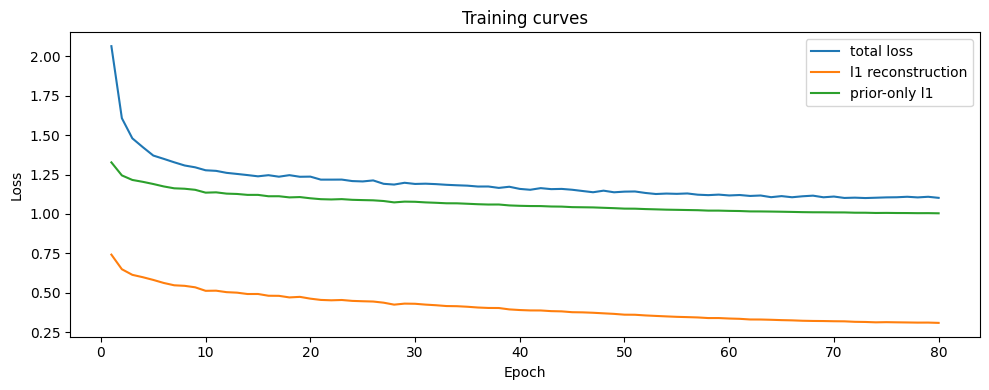

In [8]:
def denormalize_mel(mel_tensor):
    mean = torch.as_tensor(mel_mean, dtype=mel_tensor.dtype, device=mel_tensor.device)
    std = torch.as_tensor(mel_std, dtype=mel_tensor.dtype, device=mel_tensor.device)
    return mel_tensor * std + mean


def plot_mel(mel, title):
    lower = float(globals().get("mel_min", np.min(mel)))
    upper = float(globals().get("mel_max", np.max(mel)))
    plt.figure(figsize=(12, 4))
    plt.imshow(mel.T, origin="lower", aspect="auto", interpolation="nearest", vmin=lower, vmax=upper, cmap="magma")
    plt.title(title)
    plt.xlabel("Frames")
    plt.ylabel("Mel bins")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


def plot_encoder_diagnostics(diagnostics, predicted_durations, tokenizer, title_prefix="Encoder"):
    text_ids = diagnostics["text_ids"].numpy()
    encoder_states = diagnostics["encoder_states"].numpy()
    log_duration_pred = diagnostics["log_duration_pred"].numpy()
    conditioning = diagnostics["conditioning"].numpy()
    token_prior_mel = diagnostics["token_prior_mel_norm"].numpy()
    predicted_durations = predicted_durations.numpy()

    token_labels = [tokenizer.id_to_symbol[int(token_id)] for token_id in text_ids]
    tick_step = max(1, len(token_labels) // 48)
    tick_positions = np.arange(0, len(token_labels), tick_step)
    tick_labels = [token_labels[idx] for idx in tick_positions]
    width = max(12, min(24, 0.35 * max(len(token_labels), 1)))
    positions = np.arange(len(token_labels))

    encoder_mean = encoder_states.mean(axis=1)
    encoder_std = encoder_states.std(axis=1)
    encoder_rms = np.sqrt(np.mean(encoder_states ** 2, axis=1))

    plt.figure(figsize=(width, 5))
    plt.imshow(encoder_states.T, origin="lower", aspect="auto", interpolation="nearest")
    plt.title(f"{title_prefix}: raw encoder states (token space)")
    plt.xlabel("Tokens")
    plt.ylabel("Hidden channels")
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(width, 4))
    plt.plot(positions, encoder_mean, marker="o", linewidth=1.2, label="mean")
    plt.plot(positions, encoder_std, marker="o", linewidth=1.2, label="std")
    plt.plot(positions, encoder_rms, marker="o", linewidth=1.2, label="rms")
    plt.title(f"{title_prefix}: encoder token summary")
    plt.xlabel("Tokens")
    plt.ylabel("Value")
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(width, 5))
    plt.imshow(token_prior_mel.T, origin="lower", aspect="auto", interpolation="nearest")
    plt.title(f"{title_prefix}: token-space encoder prior (before duration expansion)")
    plt.xlabel("Tokens")
    plt.ylabel("Mel bins")
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.imshow(conditioning.T, origin="lower", aspect="auto", interpolation="nearest")
    plt.title(f"{title_prefix}: length-regulated encoder output (frame space)")
    plt.xlabel("Frames")
    plt.ylabel("Hidden channels")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(width, 4))
    plt.bar(positions, predicted_durations, alpha=0.4, label="predicted frames")
    plt.plot(positions, log_duration_pred, marker="o", linewidth=1.5, label="log duration")
    plt.title(f"{title_prefix}: duration head output")
    plt.xlabel("Tokens")
    plt.ylabel("Value")
    plt.xticks(tick_positions, tick_labels, rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(10, 4))
plt.plot(history_df["epoch"], history_df["loss"], label="total loss")
plt.plot(history_df["epoch"], history_df["l1"], label="l1 reconstruction")
plt.plot(history_df["epoch"], history_df["prior"], label="prior-only l1")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training curves")
plt.legend()
plt.tight_layout()
plt.show()

def log_mel_to_audio(log_mel, config, n_iter=32):
    lower = float(globals().get("mel_min", np.log(1e-5)))
    upper = float(globals().get("mel_max", 8.0))
    safe_log_mel = np.asarray(log_mel, dtype=np.float32)
    safe_log_mel = np.nan_to_num(safe_log_mel, nan=lower, neginf=lower, posinf=upper)
    safe_log_mel = np.clip(safe_log_mel, lower, upper)
    mel_power = np.exp(safe_log_mel).T.astype(np.float32)
    mel_power = np.nan_to_num(mel_power, nan=1e-5, neginf=1e-5, posinf=float(np.exp(upper)))
    mel_power = np.clip(mel_power, 1e-5, float(np.exp(upper)))
    audio = librosa.feature.inverse.mel_to_audio(
        mel_power,
        sr=config.sample_rate,
        n_fft=config.n_fft,
        hop_length=config.hop_length,
        win_length=config.win_length,
        fmin=config.fmin,
        fmax=config.fmax,
        power=2.0,
        n_iter=n_iter,
    )
    audio = np.nan_to_num(audio, nan=0.0, neginf=0.0, posinf=0.0)
    if np.max(np.abs(audio)) > 0:
        audio = librosa.util.normalize(audio)
    return audio.astype(np.float32)


def load_reference_audio(item, config):
    wav_path = config.wav_dir / f"{item['item_id']}.wav"
    audio, _ = librosa.load(wav_path, sr=config.sample_rate)
    return audio.astype(np.float32)


def show_audio_player(audio, sample_rate, label):
    print(label)
    display(Audio(audio, rate=sample_rate))

## Reference Pass

Below, the system receives a known prompt and predicts timing on its own. This serves as a sanity check for overall shape, pacing, and internal consistency.


Predicted total frames: 811
First predicted durations: [3, 6, 3, 4, 9, 6, 3, 3, 0, 21, 15, 2, 4, 3, 2, 3, 7, 5, 4, 6]


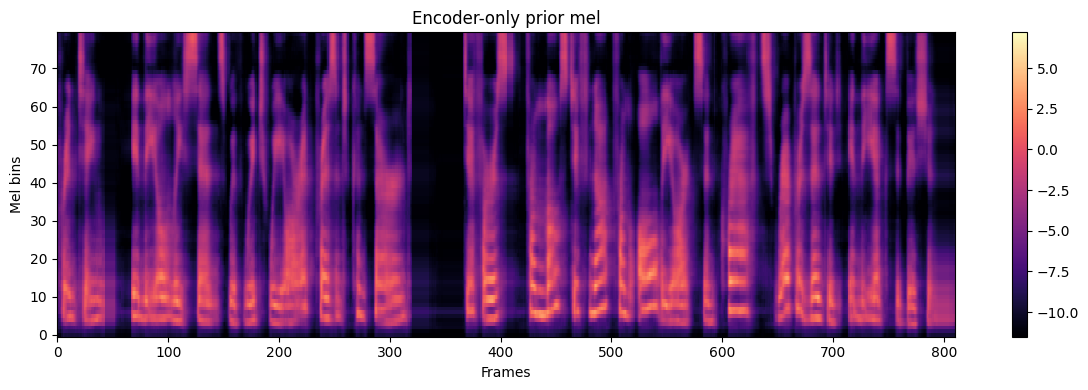

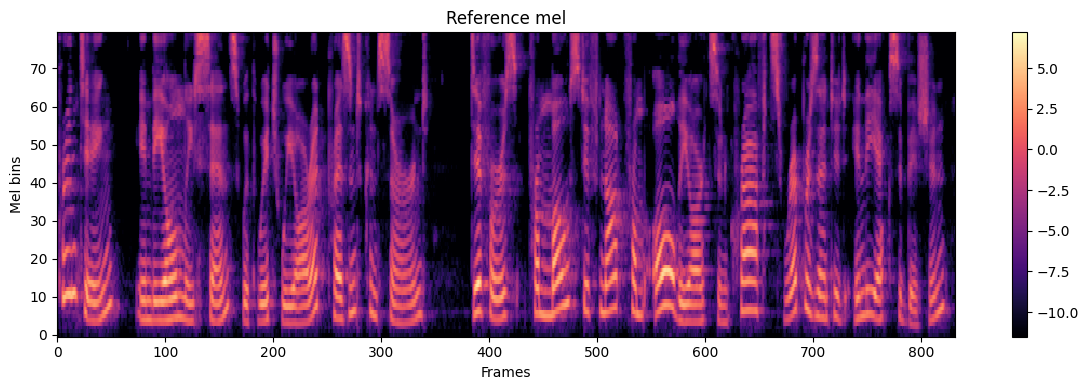

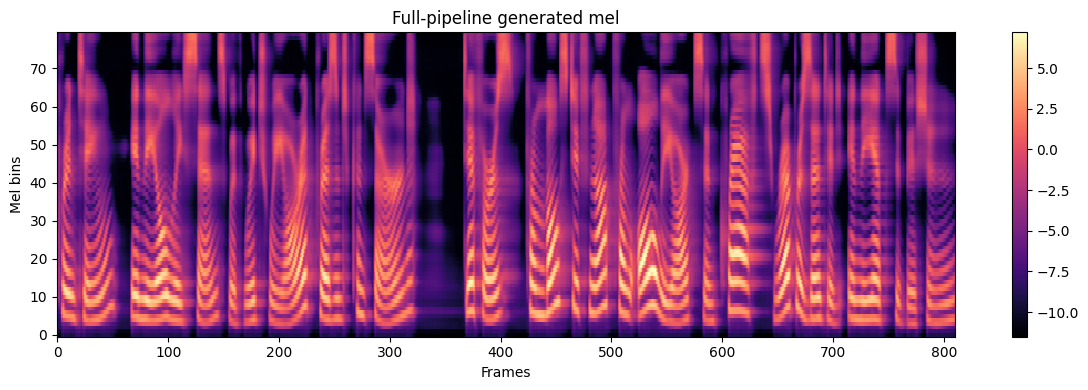

In [13]:
train_item = items[0]
reference_mel = train_item["mel_raw"]
reference_audio = load_reference_audio(train_item, config)

generated_mel_norm, predicted_durations, encoder_diagnostics = model.synthesize(
    train_item["text"],
    tokenizer,
    noise_levels=noise_levels,
    temperature=config.inference_temperature,
)

generated_mel = denormalize_mel(generated_mel_norm).numpy()
encoder_prior_mel = denormalize_mel(encoder_diagnostics["prior_mel_norm"]).numpy()
print("Predicted total frames:", int(predicted_durations.sum()))
print("First predicted durations:", predicted_durations[:20].tolist())

plot_mel(encoder_prior_mel, "Encoder-only prior mel")
plot_mel(reference_mel, "Reference mel")
plot_mel(generated_mel, "Full-pipeline generated mel")


## Listening Comparison

Two signals are compared here:

- `expected` is the reference signal
- `obtained` is the reconstructed signal produced by the full pipeline

The reconstruction stage is intentionally simple, so the resulting sound is rougher than the reference. The more important comparison here is rhythm, pauses, and overall phrase structure.


In [10]:
generated_audio = log_mel_to_audio(generated_mel, config, n_iter=48)
encoder_prior_audio = log_mel_to_audio(encoder_prior_mel, config, n_iter=48)

show_audio_player(reference_audio, config.sample_rate, "Expected audio")
show_audio_player(encoder_prior_audio, config.sample_rate, "Encoder-only prior audio")
show_audio_player(generated_audio, config.sample_rate, "Obtained audio from full pipeline")

Expected audio


Encoder-only prior audio


Obtained audio from full pipeline


## Open Prompt

In this block, you can enter an arbitrary phrase and immediately get:

- a generated spectral representation
- a reconstructed audio preview

This is the free-form pass for text that was not part of the observed pairs.


In [11]:
train_item["text"]

'printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the exhibition'

In [14]:
custom_text = widgets.Textarea(
    value="this is a simple test sentence",
    description="Text:",
    layout=widgets.Layout(width="100%", height="100px"),
)
temperature_slider = widgets.FloatSlider(
    value=config.inference_temperature,
    min=0.0,
    max=0.5,
    step=0.05,
    description="Temp:",
    continuous_update=False,
)
generate_button = widgets.Button(
    description="Generate",
    button_style="success",
    icon="play",
)
custom_output = widgets.Output()


def generate_from_custom_text(_):
    text = normalize_text(custom_text.value)
    with custom_output:
        clear_output(wait=True)

        if not text:
            print("Enter non-empty text.")
            return

        generated_mel_norm, predicted_durations, encoder_diagnostics = model.synthesize(
            text,
            tokenizer,
            noise_levels=noise_levels,
            temperature=float(temperature_slider.value),
        )

        generated_mel = denormalize_mel(generated_mel_norm).numpy()
        encoder_prior_mel = denormalize_mel(encoder_diagnostics["prior_mel_norm"]).numpy()
        generated_audio = log_mel_to_audio(generated_mel, config, n_iter=48)
        encoder_prior_audio = log_mel_to_audio(encoder_prior_mel, config, n_iter=48)

        print("Input text:", text)
        print("Predicted total frames:", int(predicted_durations.sum()))
        print("First predicted durations:", predicted_durations[:20].tolist())
        plot_mel(encoder_prior_mel, "Encoder-only prior mel")
        plot_mel(generated_mel, "Generated mel for custom text")
        show_audio_player(encoder_prior_audio, config.sample_rate, "Encoder-only prior audio")
        show_audio_player(generated_audio, config.sample_rate, "Generated audio")


generate_button.on_click(generate_from_custom_text)

display(
    widgets.VBox(
        [
            custom_text,
            temperature_slider,
            generate_button,
            custom_output,
        ]
    )
)

## Closing Note

After optimization, the system can turn text into a spectral sequence and reconstruct an audible result from it. The sound remains rough by design, but the full workflow is visible end to end and suitable for demonstration and inspection.
